# Stroke Prediction — Data Cleaning & Feature Engineering

Pipeline:
1. Drop the patient `id`
2. Drop the single `gender == "Other"` row
3. Impute the 201 missing `bmi` values with the median
4. Engineer `age_group`, `bmi_category`, `glucose_category`, `high_risk_flag`
5. One-hot encode all categorical features (`drop_first=True`)
6. Save to `data/stroke_cleaned.csv`

## 1. Imports & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append(".")
from utils import (load_data, drop_id, drop_rare_gender, impute_bmi,
                   create_features, preprocess_data)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

%matplotlib inline

In [2]:
df = load_data("data/stroke.csv")
print(f"Raw shape: {df.shape}")
df.head()

Raw shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 2. Missing / Invalid Values

In [3]:
missing = df.isnull().sum()
print(missing[missing>0])
print(f"\nDuplicate rows: {df.duplicated().sum()}")

bmi    201
dtype: int64

Duplicate rows: 0


## 3. Drop ID & 'Other' Gender Row

In [4]:
df_no_id = drop_id(df)
df_no_gender = drop_rare_gender(df_no_id)
print(f"After drops: {df_no_gender.shape}")
print(df_no_gender['gender'].value_counts())

After drops: (5109, 11)
gender
Female    2994
Male      2115
Name: count, dtype: int64


## 4. Impute BMI

In [5]:
df_imp = impute_bmi(df_no_gender, strategy="median")
print(f"BMI missing after imputation: {df_imp['bmi'].isnull().sum()}")
print(f"BMI median used: {df_no_gender['bmi'].median():.2f}")

BMI missing after imputation: 0
BMI median used: 28.10


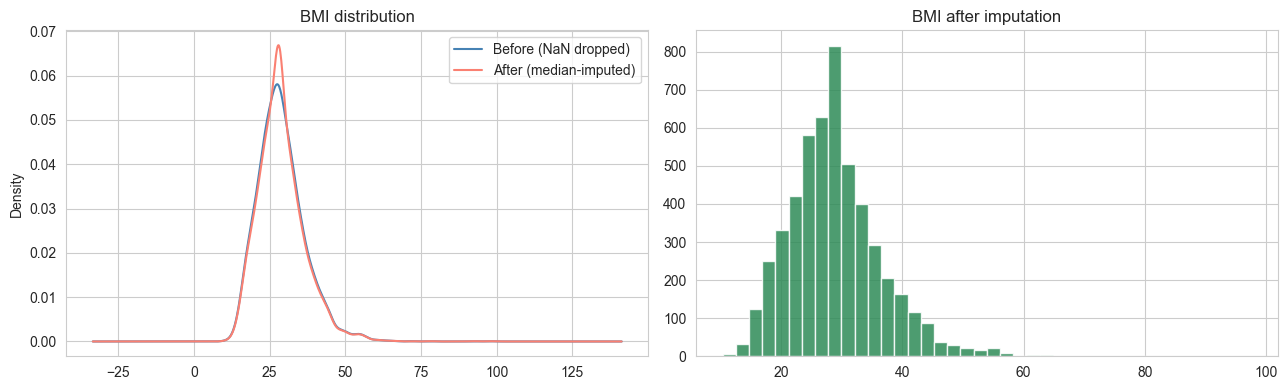

In [6]:
# Compare BMI before vs after imputation
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df_no_gender["bmi"].dropna().plot(kind="kde", ax=axes[0], color="steelblue", label="Before (NaN dropped)")
df_imp["bmi"].plot(kind="kde", ax=axes[0], color="salmon", label="After (median-imputed)")
axes[0].set_title("BMI distribution"); axes[0].legend()

axes[1].hist(df_imp["bmi"], bins=40, color="seagreen", edgecolor="white", alpha=0.85)
axes[1].set_title("BMI after imputation")
plt.tight_layout(); plt.show()

## 5. Feature Engineering

In [7]:
df_feat = create_features(df_imp)
new_cols = [c for c in df_feat.columns if c not in df_imp.columns]
print(f"New features: {new_cols}")
df_feat[new_cols + ["stroke"]].head()

New features: ['age_group', 'bmi_category', 'glucose_category', 'high_risk_flag']


,age_group,bmi_category,glucose_category,high_risk_flag,stroke
0,elderly,obese,diabetic,1,1
1,senior,overweight,diabetic,1,1
2,elderly,obese,prediabetic,1,1
3,middle_aged,obese,diabetic,1,1
4,elderly,normal,diabetic,1,1


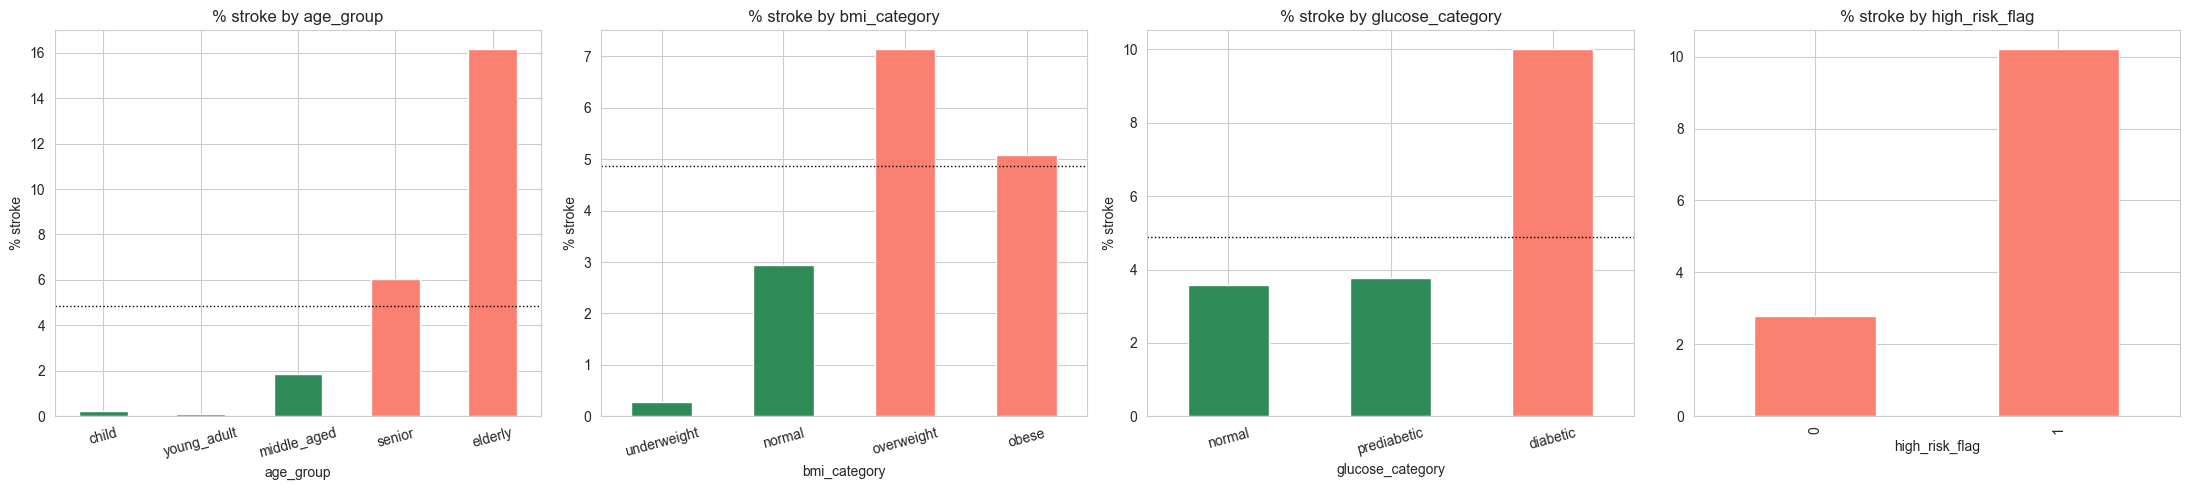

In [8]:
# Visualize new categorical bins by stroke
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for i, col in enumerate(new_cols):
    if df_feat[col].dtype.name == "category" or df_feat[col].dtype == object:
        rate = df_feat.groupby(col, observed=True)["stroke"].mean() * 100
        rate.plot(kind="bar", ax=axes[i],
                  color=["salmon" if r > df_feat["stroke"].mean()*100 else "seagreen" for r in rate])
        axes[i].axhline(df_feat["stroke"].mean()*100, color="black", linestyle=":", linewidth=1)
        axes[i].set_title(f"% stroke by {col}")
        axes[i].set_ylabel("% stroke"); axes[i].tick_params(axis="x", rotation=15)
    else:
        rate = df_feat.groupby(col)["stroke"].mean() * 100
        rate.plot(kind="bar", ax=axes[i], color="salmon")
        axes[i].set_title(f"% stroke by {col}")
plt.tight_layout(); plt.show()

## 6. Run the Full Pipeline

In [9]:
df_processed = preprocess_data(df)
print(f"Processed shape: {df_processed.shape}")
print(f"Missing values : {df_processed.isnull().sum().sum()}")
df_processed.head()

Processed shape: (5109, 26)
Missing values : 0


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,high_risk_flag,gender_Male,ever_married_Yes,work_type_Never_worked,...,smoking_status_smokes,age_group_young_adult,age_group_middle_aged,age_group_senior,age_group_elderly,bmi_category_normal,bmi_category_overweight,bmi_category_obese,glucose_category_prediabetic,glucose_category_diabetic
0,67.0,0,1,228.69,36.6,1,1,1,1,0,...,0,0,0,0,1,0,0,1,0,1
1,61.0,0,0,202.21,28.1,1,1,0,1,0,...,0,0,0,1,0,0,1,0,0,1
2,80.0,0,1,105.92,32.5,1,1,1,1,0,...,0,0,0,0,1,0,0,1,1,0
3,49.0,0,0,171.23,34.4,1,1,0,1,0,...,1,0,1,0,0,0,0,1,0,1
4,79.0,1,0,174.12,24.0,1,1,0,1,0,...,0,0,0,0,1,1,0,0,0,1


## 7. Sanity Checks & Save

In [10]:
assert df_processed["stroke"].isin([0, 1]).all()
assert df_processed.isnull().sum().sum() == 0
assert "id" not in df_processed.columns
print("All checks passed.")

All checks passed.


In [11]:
df_processed.to_csv("data/stroke_cleaned.csv", index=False)
print(f"Saved data/stroke_cleaned.csv ({df_processed.shape[0]} rows, {df_processed.shape[1]} cols)")

Saved data/stroke_cleaned.csv (5109 rows, 26 cols)
